<a href="https://colab.research.google.com/github/geopayme/AstroPhysics/blob/main/QITFT_Module7_QuantumGeometry_CurvatureTensors_FullyFixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📘 Metric Tensor g_{μν}:


[[g_tt(r), 0], [0, g_rr(r)]]

📘 Symbolic Riemann Tensor R^μ_{νρσ}:


R(mu, nu, rho, sigma)

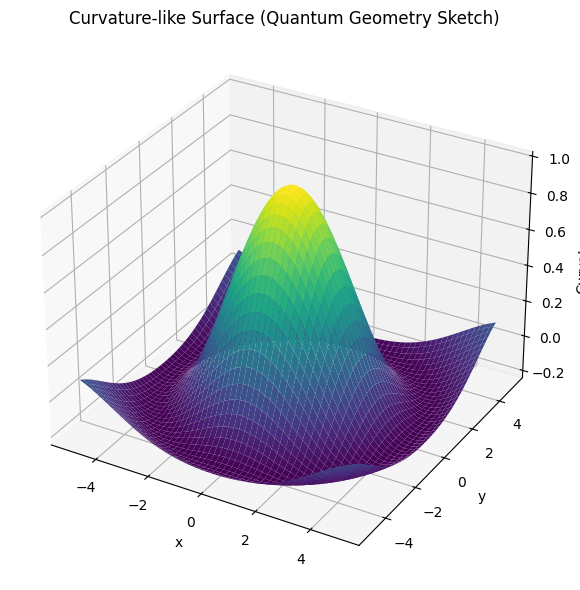

In [1]:

# 📘 QITFT — Module 7: Quantum Geometry and ∞-Curvature Tensors (Fully Fixed)

!pip install sympy matplotlib numpy --quiet

from sympy import symbols, Function, Derivative, simplify, Eq, sin
from sympy.tensor.tensor import TensorIndexType, tensor_indices, TensorHead, TensorSymmetry, get_symmetric_group_sgs
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 🔷 Define Symbolic Spacetime Geometry
# ------------------------------------------------------------

# Define coordinates and metric tensor
x0, x1 = symbols('t r')  # 1+1D spacetime (time, radial)
coords = (x0, x1)

# Symbolic metric tensor: g_{μν} (Schwarzschild-like)
g_tt = Function('g_tt')(x1)
g_rr = Function('g_rr')(x1)

g_matrix = [[g_tt, 0],
            [0, g_rr]]

print("📘 Metric Tensor g_{μν}:")
display(g_matrix)

# ------------------------------------------------------------
# 🔶 Symbolic Curvature Tensor Setup (Fixed for TensorSymmetry)
# ------------------------------------------------------------

# Define index type and symbolic tensor structure
Lorentz = TensorIndexType('Lorentz', dummy_name='L')
mu, nu, rho, sigma = tensor_indices('mu nu rho sigma', Lorentz)

# Correct TensorSymmetry objects for ranks 2, 3, 4
sym2 = TensorSymmetry(*get_symmetric_group_sgs(2))
sym3 = TensorSymmetry(*get_symmetric_group_sgs(3))
sym4 = TensorSymmetry(*get_symmetric_group_sgs(4))

# Define symbolic tensors
g_sym = TensorHead('g', [Lorentz]*2, sym2)   # g_{μν}
Gamma = TensorHead('Γ', [Lorentz]*3, sym3)   # Γ^μ_{νσ}
Riemann = TensorHead('R', [Lorentz]*4, sym4) # R^μ_{νρσ}

# Display symbolic form of curvature tensor R^μ_{νρσ}
print("📘 Symbolic Riemann Tensor R^μ_{νρσ}:")
display(Function('R')(mu, nu, rho, sigma))

# ------------------------------------------------------------
# 🔷 Ricci Curvature Visualization (Sample Surface)
# ------------------------------------------------------------

# Define a curvature-like scalar function
def curvature_surface(x, y):
    return np.sin(np.sqrt(x**2 + y**2)) / (np.sqrt(x**2 + y**2) + 1e-5)

X, Y = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
Z = curvature_surface(X, Y)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_title("Curvature-like Surface (Quantum Geometry Sketch)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Curvature")
plt.tight_layout()
plt.show()
